In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
## The specific dataset I had didn't really face any missing values, so I could have theoretically taken the approach of just telling my algorithms to ignore any incomplete entries. However, just in case, I went the route of replacing any blank values with averages gathered from the other values, so the blank entry would still be counted, it would just stay squarely in the middle.

##In relation to one-hot encoding, I didn't find this to be necessary with my specific dataset. Every entry into my table was a numeric value. The only place I could have seen this being necessary was if the data was compiled into one table and, for example, there was a dedicated column for "Red or White", consisting of values like "Red" or "White." However, these, too, were presented as two distinct tables. So no modification was necessary.

Accuracy:  0.9663265306122449
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        30
           1       0.97      1.00      0.98       950

    accuracy                           0.97       980
   macro avg       0.48      0.50      0.49       980
weighted avg       0.94      0.97      0.95       980



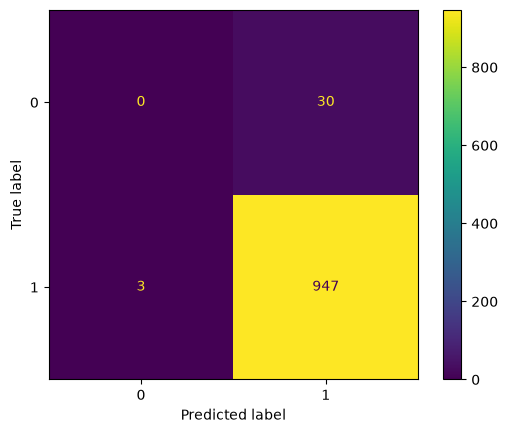

                 Feature  Coefficient
0          fixed acidity    -0.249522
1       volatile acidity    -0.624072
2            citric acid    -0.000115
3         residual sugar     0.995663
4              chlorides    -0.027840
5    free sulfur dioxide     0.441454
6   total sulfur dioxide     0.235519
7                density    -0.728098
8                     pH    -0.047183
9              sulphates     0.144954
10               alcohol     0.317997


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('winequality-white.csv', sep=';')
##df = pd.read_csv('winequality-red.csv', sep=';')

df.isnull().sum()
df.fillna(df.mean(), inplace=True)

df["quality"] = (df["quality"] >= 5).astype(int)
x = df.drop("quality", axis=1) # attributes of the wine
y = df["quality"] #  value to predict [quality]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#Logistic Regression to separate wines of good quality from ones of not good quality.

lr = LogisticRegression(max_iter=500)
lr.fit(x_train, y_train)


predictions = lr.predict(x_test)
accuracy = accuracy_score(y_test, predictions)

print("Accuracy: ", accuracy)
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_estimator(lr, x_test, y_test)
plt.show()

coef = pd.DataFrame({"Feature": x.columns, "Coefficient": lr.coef_[0]})
print(coef)

Accuracy:  0.9693877551020408
              precision    recall  f1-score   support

           0       0.50      0.17      0.25        30
           1       0.97      0.99      0.98       950

    accuracy                           0.97       980
   macro avg       0.74      0.58      0.62       980
weighted avg       0.96      0.97      0.96       980



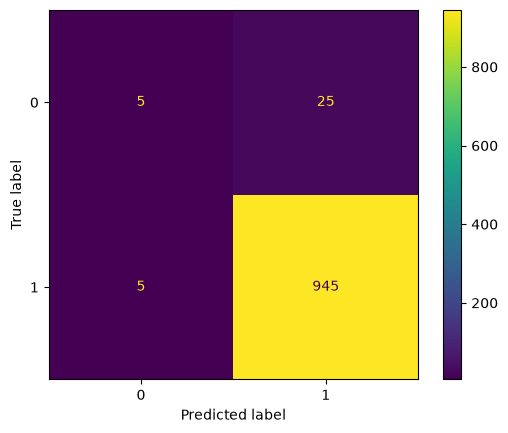

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('winequality-white.csv', sep=';')
##df = pd.read_csv('winequality-red.csv', sep=';')

df.isnull().sum()
df.fillna(df.mean(), inplace=True)

df["quality"] = (df["quality"] >= 5).astype(int)
x = df.drop("quality", axis=1) # attributes of the wine
y = df["quality"] #  value to predict [quality]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#KNN to base predictions off of other wines with similar attributes outside of quality.

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

predictions = knn.predict(x_test)
accuracy = accuracy_score(y_test, predictions)

print("Accuracy: ", accuracy)
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_estimator(knn, x_test, y_test)
plt.show()

Accuracy:  0.9510204081632653
              precision    recall  f1-score   support

           0       0.29      0.40      0.33        30
           1       0.98      0.97      0.97       950

    accuracy                           0.95       980
   macro avg       0.63      0.68      0.65       980
weighted avg       0.96      0.95      0.95       980



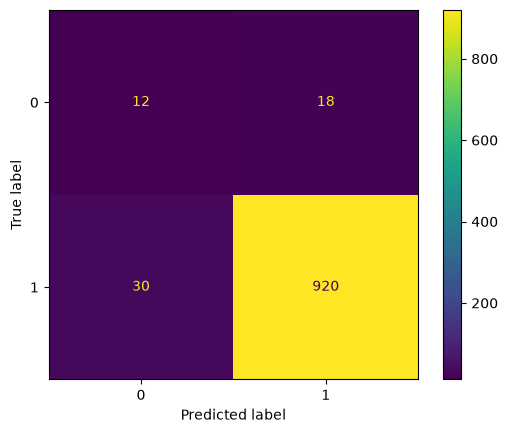

                 Feature  Importance
0          fixed acidity    0.059534
1       volatile acidity    0.135002
2            citric acid    0.085952
3         residual sugar    0.091244
4              chlorides    0.105734
5    free sulfur dioxide    0.132633
6   total sulfur dioxide    0.082137
7                density    0.094650
8                     pH    0.088204
9              sulphates    0.062005
10               alcohol    0.062904


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('winequality-white.csv', sep=';')
##df = pd.read_csv('winequality-red.csv', sep=';')

df.isnull().sum()
df.fillna(df.mean(), inplace=True)

df["quality"] = (df["quality"] >= 5).astype(int)
x = df.drop("quality", axis=1) # attributes of the wine
y = df["quality"] #  value to predict [quality]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#Using a decision tree to predict common pathways towards goodness or badness.

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

predictions = dt.predict(x_test)
accuracy = accuracy_score(y_test, predictions)

print("Accuracy: ", accuracy)
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_estimator(dt, x_test, y_test)
plt.show()

coef = pd.DataFrame({"Feature": x.columns, "Importance": dt.feature_importances_})
print(coef)

Accuracy:  0.9704081632653061
              precision    recall  f1-score   support

           0       1.00      0.03      0.06        30
           1       0.97      1.00      0.98       950

    accuracy                           0.97       980
   macro avg       0.99      0.52      0.52       980
weighted avg       0.97      0.97      0.96       980



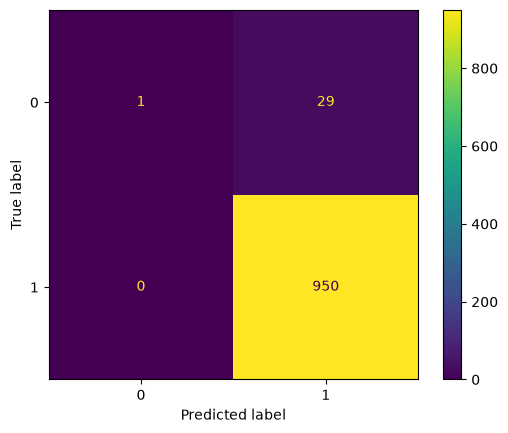

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('winequality-white.csv', sep=';')
##df = pd.read_csv('winequality-red.csv', sep=';')

df.isnull().sum()
df.fillna(df.mean(), inplace=True)

df["quality"] = (df["quality"] >= 5).astype(int)
x = df.drop("quality", axis=1) # attributes of the wine
y = df["quality"] #  value to predict [quality]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# SVM to predict based on distinctions in groupings

svm = SVC()
svm.fit(x_train, y_train)

predictions = svm.predict(x_test)
accuracy = accuracy_score(y_test, predictions)

print("Accuracy: ", accuracy)
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_estimator(svm, x_test, y_test)
plt.show()